# BK Sentinel — Notebook 02: Layer 1 Classification

**Project:** BK Sentinel — Three-Layer Dynamic Credit Risk Transition System  

---

This notebook covers Layer 1 of BK Sentinel:
1. Load the verified panel dataset from Notebook 01
2. Build trajectory and threshold features (key for High/Medium recall)
3. Train/test split (time-based)
4. SMOTE to balance all four risk classes
5. Train Logistic Regression (baseline)
6. Train Random Forest (champion candidate)
7. Train XGBoost (runner-up candidate)
8. Full comparison — Macro F1, per-class recall, Transition MAE
9. SHAP explainability on best model
10. Save best model artifacts

**Target:** Predict `next_risk_state` (Low, Medium, High, Default)  
**Selection criteria:** Macro F1, High + Default recall, Transition MAE

In [155]:
import sys
!{sys.executable} -m pip install imbalanced-learn shap xgboost --quiet


/Users/df-9/.zshenv:export:1: not valid in this context: Support/JetBrains/Toolbox/scripts://Users/df-9/development/flutter/bin:/Users/df-9/.rvm/bin:/Users/df-9/fvm/default/bin

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, accuracy_score,
    precision_score, cohen_kappa_score
)
from imblearn.over_sampling import SMOTE

import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

RISK_MAP    = {'Low': 0, 'Medium': 1, 'High': 2, 'Default': 3}
RISK_LABELS = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Default'}
CLASS_NAMES = ['Low', 'Medium', 'High', 'Default']

print('Libraries imported.')


Libraries imported.


## 1. Load the verified dataset

In [157]:
df = pd.read_csv('bk_sentinel_verified.csv', low_memory=False)

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Months: {sorted(df["observation_month"].unique())}')
print(f'Accounts: {df["loan_id"].nunique():,}')
print(f'\nrisk_state distribution:')
print(df['risk_state'].value_counts())


Dataset loaded: 67,888 rows x 39 columns
Months: ['2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
Accounts: 4,232

risk_state distribution:
risk_state
Low        45946
Medium      9768
Default     7374
High        4800
Name: count, dtype: int64


## 2. Feature Engineering

We build **trajectory features** (where the account came from, how fast it is moving)
and **threshold-proximity features** (how close to the next DPD band boundary).  
These are the signals that distinguish e.g. Medium accounts heading to High from
Medium accounts that will stay or recover.

In [158]:
df = df.sort_values(['loan_id', 'observation_month']).reset_index(drop=True)

# ── 1. Lag: previous-month risk state and DPD ──────────────────────────────
df['prev_risk_state_code'] = (
    df.groupby('loan_id')['risk_state_code'].shift(1)
      .fillna(df['risk_state_code']).astype(int)
)
df['prev_dpd']         = df.groupby('loan_id')['days_in_arrears'].shift(1).fillna(0)
df['dpd_delta']        = (df['days_in_arrears'] - df['prev_dpd']).fillna(0)

# 2-month and 3-month DPD velocity (captures acceleration)
df['prev_dpd_2m']      = df.groupby('loan_id')['days_in_arrears'].shift(2).fillna(0)
df['dpd_velocity_2m']  = (df['days_in_arrears'] - df['prev_dpd_2m']).fillna(0)
df['prev_dpd_3m']      = df.groupby('loan_id')['days_in_arrears'].shift(3).fillna(0)
df['dpd_velocity_3m']  = (df['days_in_arrears'] - df['prev_dpd_3m']).fillna(0)

# ── 2. Consecutive months in current state (streak) ───────────────────────
prev_state        = df.groupby('loan_id')['risk_state'].shift(1)
state_changed     = (prev_state != df['risk_state']) | prev_state.isna()
df['_streak_id']  = state_changed.groupby(df['loan_id']).cumsum()
df['months_in_state'] = df.groupby(['loan_id', '_streak_id']).cumcount() + 1
df.drop(columns=['_streak_id'], inplace=True)

# ── 3. Position within current DPD band (0 = just entered, 1 = top) ───────
dpd = df['days_in_arrears']
conditions = [
    df['risk_state'] == 'Low',
    df['risk_state'] == 'Medium',
    df['risk_state'] == 'High',
    df['risk_state'] == 'Default',
]
choices = [
    dpd / 3.0,
    (dpd - 5).clip(lower=0) / 24.0,
    (dpd - 31).clip(lower=0) / 58.0,
    (dpd / 280.0).clip(upper=1.0),
]
df['dpd_band_position'] = np.select(conditions, choices, default=0.0).clip(0, 1)

# ── 4. Projected next-month DPD (linear extrapolation) ────────────────────
# This is the most powerful feature for predicting state transitions
df['projected_dpd_next']  = (dpd + df['dpd_delta']).clip(lower=0)
df['proj_will_be_high']   = ((df['projected_dpd_next'] >= 31) & (df['projected_dpd_next'] <= 90)).astype(int)
df['proj_will_be_default']= (df['projected_dpd_next'] > 90).astype(int)
df['proj_will_be_medium'] = ((df['projected_dpd_next'] >= 1)  & (df['projected_dpd_next'] <= 30)).astype(int)
df['proj_will_be_low']    = (df['projected_dpd_next'] == 0).astype(int)

# Velocity-weighted projection (more robust than raw delta)
df['smooth_velocity']    = df['dpd_delta'] * 0.6 + df['dpd_velocity_2m'] / 2 * 0.4
df['smooth_proj_dpd']    = (dpd + df['smooth_velocity']).clip(lower=0)
df['smooth_proj_high']   = ((df['smooth_proj_dpd'] >= 31) & (df['smooth_proj_dpd'] <= 90)).astype(int)
df['smooth_proj_default']= (df['smooth_proj_dpd'] > 90).astype(int)

# ── 5. Direction flags ────────────────────────────────────────────────────
df['transitioning_up']   = (df['risk_state_code'] > df['prev_risk_state_code']).astype(int)
df['transitioning_down'] = (df['risk_state_code'] < df['prev_risk_state_code']).astype(int)

# ── 6. Band-boundary proximity flags ─────────────────────────────────────
df['near_high_threshold']    = ((dpd >= 22) & (dpd <= 30)).astype(int)  # approaching High
df['near_default_threshold'] = ((dpd >= 75) & (dpd <= 90)).astype(int)  # approaching Default
df['near_medium_threshold']  = ((dpd >= 1)  & (dpd <= 8)).astype(int)   # just entered Medium

print(f'Features engineered. DataFrame now has {df.shape[1]} columns.')
print(f'  prev_risk_state_code  — prev-month state (0-3)')
print(f'  months_in_state       — consecutive months in current state')
print(f'  dpd_delta             — DPD change from last month')
print(f'  dpd_velocity_2m/3m    — DPD change over 2 / 3 months')
print(f'  dpd_band_position     — position within current band (0=just entered, 1=top)')
print(f'  projected_dpd_next    — naive linear extrapolation of next DPD')
print(f'  proj_will_be_*        — binary flags: which band the projection lands in')
print(f'  smooth_proj_*         — velocity-weighted projection (more robust)')
print(f'  near_*_threshold      — proximity to DPD band boundaries')


Features engineered. DataFrame now has 62 columns.
  prev_risk_state_code  — prev-month state (0-3)
  months_in_state       — consecutive months in current state
  dpd_delta             — DPD change from last month
  dpd_velocity_2m/3m    — DPD change over 2 / 3 months
  dpd_band_position     — position within current band (0=just entered, 1=top)
  projected_dpd_next    — naive linear extrapolation of next DPD
  proj_will_be_*        — binary flags: which band the projection lands in
  smooth_proj_*         — velocity-weighted projection (more robust)
  near_*_threshold      — proximity to DPD band boundaries


## 3. Encode categoricals and define feature matrix

In [159]:
le_segment   = LabelEncoder()
le_loan_type = LabelEncoder()
df['segment_enc']   = le_segment.fit_transform(df['segment'].astype(str).fillna('UNKNOWN'))
df['loan_type_enc'] = le_loan_type.fit_transform(df['loan_type'].astype(str).fillna('UNKNOWN'))

df['target_code'] = df['next_risk_state'].map(RISK_MAP)

# ─── SINGLE definition of feature list — no duplicate below ────────────────
NUMERIC_FEATURES = [
    # Core arrears signals
    'days_in_arrears',
    'instalments_in_arrears',
    'arrears_ratio',
    'repayment_ratio',
    # Trajectory / lag features  ←  KEY for High and Medium recall
    'prev_risk_state_code',    # state last month (0-3)
    'months_in_state',         # how long stuck in current state
    'dpd_band_position',       # how far into current band (0=just entered, 1=top)
    'dpd_delta',               # DPD change last month (+ = deteriorating)
    'dpd_velocity_2m',         # DPD change over 2 months
    'dpd_velocity_3m',         # DPD change over 3 months
    # Projected next-month DPD features  ←  NEW, strong boundary signals
    'projected_dpd_next',      # naive linear extrapolation
    'proj_will_be_high',       # 1 if projection lands in High band
    'proj_will_be_default',    # 1 if projection lands in Default band
    'proj_will_be_medium',     # 1 if projection lands in Medium band
    'proj_will_be_low',        # 1 if projection lands in Low
    'smooth_velocity',         # velocity-weighted DPD trend
    'smooth_proj_dpd',         # smooth projected DPD
    'smooth_proj_high',        # smooth projection → High?
    'smooth_proj_default',     # smooth projection → Default?
    # Direction flags
    'transitioning_up',        # just moved up a risk band this month
    'transitioning_down',      # just moved down a risk band this month
    # Band-boundary proximity
    'near_high_threshold',     # DPD 22-30 (approaching High)
    'near_default_threshold',  # DPD 75-90 (approaching Default)
    'near_medium_threshold',   # DPD 1-8 (just entered Medium)
    # Financial features
    'principal_balance',
    'principal_due',
    'penal_interest',
    'suspended_interest',
    'interest_due',
    'accrued_interest',
    # Loan characteristics
    'all_crb',
    'interest_rate',
    'loan_term_months',
    'number_instalments_paid',
    'disbursed_amount_lcy',
    'loan_age_months',
]

CATEGORICAL_FEATURES = ['segment_enc', 'loan_type_enc']
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

TARGET = 'next_risk_state'
df_ml = df.dropna(subset=[TARGET]).copy()
df_ml[FEATURE_COLS] = df_ml[FEATURE_COLS].fillna(0)

print(f'Total feature columns: {len(FEATURE_COLS)}')
print(f'Records with valid target: {len(df_ml):,}')
print(f'\nTarget distribution:')
print(df_ml[TARGET].value_counts())


Total feature columns: 38
Records with valid target: 63,656

Target distribution:
next_risk_state
Low        42428
Medium      9537
Default     7334
High        4357
Name: count, dtype: int64


## 4. Time-based train-test split

In [160]:
months      = sorted(df_ml['observation_month'].unique())
train_months = months[:-2]   # months 1-14
test_months  = months[-2:]   # months 15-16

print(f'Training months ({len(train_months)}): {train_months}')
print(f'Test months    ({len(test_months)}):  {test_months}')

train_idx = df_ml['observation_month'].isin(train_months)
test_idx  = df_ml['observation_month'].isin(test_months)

X_train = df_ml.loc[train_idx, FEATURE_COLS].values
X_test  = df_ml.loc[test_idx,  FEATURE_COLS].values
y_train = df_ml.loc[train_idx, 'target_code'].values
y_test  = df_ml.loc[test_idx,  'target_code'].values

print(f'\nTraining set: {X_train.shape[0]:,} records')
print(f'Test set:     {X_test.shape[0]:,} records')
print(f'\nTraining distribution (before SMOTE):')
for code, label in RISK_LABELS.items():
    n = (y_train == code).sum()
    print(f'  {label}: {n:,} ({n/len(y_train)*100:.1f}%)')


Training months (14): ['2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
Test months    (2):  ['2025-12', '2026-01']

Training set: 59,402 records
Test set:     4,254 records

Training distribution (before SMOTE):
  Low: 39,735 (66.9%)
  Medium: 9,304 (15.7%)
  High: 4,233 (7.1%)
  Default: 6,130 (10.3%)


## 5. High-Risk Augmentation + SMOTE

The High class has only **3,914 training records** — just 7% of the training set —
while Low has 32,023 (58%). This extreme imbalance is the primary reason the model
struggles to recognise High-risk accounts: it has barely seen them.

We fix this with a **two-step strategy**:

**Step 1 — Targeted augmentation:** We generate synthetic High-labelled records by
taking every real High training record and creating 4 perturbed copies using
small Gaussian noise (σ = 5% of each feature value). DPD is clamped to its correct
BNR band so the derived threshold features remain consistent. This takes High from
3,914 to ~19,570 records before SMOTE ever runs.

**Step 2 — SMOTE:** Applied on the augmented set. Because High now has a much
richer and more diverse base (19,570 vs 3,914), the synthetic SMOTE points it
generates are far more informative — they interpolate across a wider range of
realistic High-risk feature combinations rather than tiny clusters.

The test set is never touched.

In [162]:
# ── Feature index map ─────────────────────────────────────────────────────────
feat_idx = {f: i for i, f in enumerate(FEATURE_COLS)}

DPD_IDX         = feat_idx['days_in_arrears']
DELTA_IDX       = feat_idx['dpd_delta']
VEL2_IDX        = feat_idx['dpd_velocity_2m']
BAND_IDX        = feat_idx['dpd_band_position']
PROJ_NEXT_IDX   = feat_idx['projected_dpd_next']
PROJ_HIGH_IDX   = feat_idx['proj_will_be_high']
PROJ_DEF_IDX    = feat_idx['proj_will_be_default']
PROJ_MED_IDX    = feat_idx['proj_will_be_medium']
PROJ_LOW_IDX    = feat_idx['proj_will_be_low']
SMOOTH_VEL_IDX  = feat_idx['smooth_velocity']
SMOOTH_PROJ_IDX = feat_idx['smooth_proj_dpd']
SMOOTH_HIGH_IDX = feat_idx['smooth_proj_high']
SMOOTH_DEF_IDX  = feat_idx['smooth_proj_default']
NEAR_HI_IDX     = feat_idx['near_high_threshold']
NEAR_DEF_IDX    = feat_idx['near_default_threshold']
NEAR_MED_IDX    = feat_idx['near_medium_threshold']


def recompute_dpd_features(row, dpd, delta, vel2):
    """Recompute all DPD-derived features after perturbing DPD / delta."""
    row = row.copy()

    # Position within current BNR band
    if   31 <= dpd <= 90: row[BAND_IDX] = (dpd - 31) / 58.0
    elif  1 <= dpd <= 30: row[BAND_IDX] = max(0, dpd - 5) / 24.0
    elif dpd == 0:        row[BAND_IDX] = 0.0
    else:                 row[BAND_IDX] = min(dpd / 280.0, 1.0)   # Default band

    # Projected next-month DPD (linear and velocity-weighted)
    proj        = max(0, dpd + delta)
    smooth_vel  = delta * 0.6 + (vel2 / 2) * 0.4
    smooth_proj = max(0, dpd + smooth_vel)

    row[PROJ_NEXT_IDX]   = proj
    row[PROJ_HIGH_IDX]   = int(31 <= proj <= 90)
    row[PROJ_DEF_IDX]    = int(proj > 90)
    row[PROJ_MED_IDX]    = int(1  <= proj <= 30)
    row[PROJ_LOW_IDX]    = int(proj == 0)
    row[SMOOTH_VEL_IDX]  = smooth_vel
    row[SMOOTH_PROJ_IDX] = smooth_proj
    row[SMOOTH_HIGH_IDX] = int(31 <= smooth_proj <= 90)
    row[SMOOTH_DEF_IDX]  = int(smooth_proj > 90)

    # Band-boundary proximity flags
    row[NEAR_HI_IDX]  = int(22 <= dpd <= 30)
    row[NEAR_DEF_IDX] = int(75 <= dpd <= 90)
    row[NEAR_MED_IDX] = int(1  <= dpd <= 8)

    return row


# ── Step 1: Targeted High-class augmentation ───────────────────────────────
#
# Strategy:  We take every training record labelled next_risk_state=High
# and generate 4 perturbed copies (σ = 5% Gaussian noise on each feature).
# DPD is clamped to the correct BNR band based on each record's current state
# (detected directly from the DPD value), and all downstream derived features
# are recomputed so the synthetic records remain internally consistent.
#
# Result:  High class grows from ~3,914 → ~19,570 BEFORE SMOTE,
# giving SMOTE a much richer base to interpolate from.

AUG_MULTIPLIER = 4      # generate 4× more High records
NOISE_SIGMA    = 0.05   # 5 % Gaussian noise on each feature value

high_idx = np.where(y_train == 2)[0]
X_high   = X_train[high_idx].astype(float)

# Detect current risk state from DPD (BNR rules, no DataFrame join needed)
raw_dpd = X_high[:, DPD_IDX]
current_state_of_high = np.select(
    [raw_dpd == 0,
     (raw_dpd >= 1)  & (raw_dpd <= 30),
     (raw_dpd >= 31) & (raw_dpd <= 90),
     raw_dpd > 90],
    ['Low', 'Medium', 'High', 'Default'],
    default='Unknown'
)

print(f'High-class training records by current state:')
for s in ['Low', 'Medium', 'High', 'Default']:
    print(f'  Currently {s}: {(current_state_of_high == s).sum():,}')

n_synthetic = len(high_idx) * AUG_MULTIPLIER
np.random.seed(42)

synth_X, synth_y = [], []

for _ in range(n_synthetic):
    base_pos  = np.random.randint(0, len(X_high))
    row       = X_high[base_pos].copy()
    cur_state = current_state_of_high[base_pos]

    # Add Gaussian noise to all features
    noise = np.random.normal(0, NOISE_SIGMA * (np.abs(row) + 0.01))
    row   = np.clip(row + noise, 0, None)

    # Clamp DPD to its correct BNR band so the synthetic record stays valid
    if cur_state == 'High':
        # Already High (DPD 31-90) — stay in that band
        row[DPD_IDX] = np.clip(row[DPD_IDX], 31, 90)

    elif cur_state == 'Medium':
        # Approaching High threshold (DPD 22-30) — ensure DPD is rising
        row[DPD_IDX]   = np.clip(row[DPD_IDX], 22, 30)
        row[DELTA_IDX] = abs(row[DELTA_IDX]) + 2   # force positive momentum

    elif cur_state == 'Default':
        # Recovering from Default (DPD > 90) — keep above 90
        row[DPD_IDX] = np.clip(row[DPD_IDX], 91, 300)

    else:   # Low
        row[DPD_IDX] = np.clip(row[DPD_IDX], 0, 30)

    # Recompute all derived features from the new DPD / delta values
    row = recompute_dpd_features(row, row[DPD_IDX], row[DELTA_IDX], row[VEL2_IDX])

    synth_X.append(row)
    synth_y.append(2)   # label stays: next_risk_state = High

X_train_aug = np.vstack([X_train, np.array(synth_X)])
y_train_aug = np.concatenate([y_train, np.array(synth_y)])

print(f'\nHigh class before augmentation: {len(high_idx):,}')
print(f'Synthetic High records added:   {n_synthetic:,}  ({AUG_MULTIPLIER}×)')
print(f'High class after augmentation:  {(y_train_aug == 2).sum():,}')
print(f'\nTraining distribution after augmentation (before SMOTE):')
for code, label in RISK_LABELS.items():
    n = (y_train_aug == code).sum()
    print(f'  {label}: {n:,} ({n/len(y_train_aug)*100:.1f}%)')


# ── Step 2: SMOTE on the augmented set ────────────────────────────────────
#
# With ~19,570 High records (vs 3,914 before), SMOTE's KNN interpolation
# now has a much richer and more diverse base to generate synthetic boundary
# examples from — especially for the critical Medium→High transition zone.

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_aug, y_train_aug)

print(f'\nAfter SMOTE — final training distribution:')
for code, label in RISK_LABELS.items():
    n = (y_train_sm == code).sum()
    print(f'  {label}: {n:,} ({n/len(y_train_sm)*100:.1f}%)')
print(f'\nTotal training records (augmented + SMOTE): {len(X_train_sm):,}')


High-class training records by current state:
  Currently Low: 124
  Currently Medium: 1,040
  Currently High: 3,066
  Currently Default: 3

High class before augmentation: 4,233
Synthetic High records added:   16,932  (4×)
High class after augmentation:  21,165

Training distribution after augmentation (before SMOTE):
  Low: 39,735 (52.1%)
  Medium: 9,304 (12.2%)
  High: 21,165 (27.7%)
  Default: 6,130 (8.0%)

After SMOTE — final training distribution:
  Low: 39,735 (25.0%)
  Medium: 39,735 (25.0%)
  High: 39,735 (25.0%)
  Default: 39,735 (25.0%)

Total training records (augmented + SMOTE): 158,940


## 6. Model 1 — Logistic Regression (baseline)

Logistic Regression is the baseline. It proves that credit risk is a non-linear
problem — if it were linear, LR would do well. Its failure sets the performance floor
and justifies the choice of tree-based ensemble methods.

In [163]:
print('Training Logistic Regression...')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=1.0,
    random_state=42
)
lr.fit(X_train_sc, y_train_sm)
y_pred_lr = lr.predict(X_test_sc)

lr_f1             = f1_score(y_test, y_pred_lr, average='macro')
lr_recall_low     = recall_score(y_test, y_pred_lr, labels=[0], average='macro')
lr_recall_medium  = recall_score(y_test, y_pred_lr, labels=[1], average='macro')
lr_recall_high    = recall_score(y_test, y_pred_lr, labels=[2], average='macro')
lr_recall_default = recall_score(y_test, y_pred_lr, labels=[3], average='macro')

print(f'\nLogistic Regression Results:')
print(f'  Macro F1:        {lr_f1:.4f}')
print(f'  Recall Low:      {lr_recall_low:.4f}')
print(f'  Recall Medium:   {lr_recall_medium:.4f}')
print(f'  Recall High:     {lr_recall_high:.4f}')
print(f'  Recall Default:  {lr_recall_default:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=CLASS_NAMES))


Training Logistic Regression...

Logistic Regression Results:
  Macro F1:        0.9444
  Recall Low:      0.8823
  Recall Medium:   0.9914
  Recall High:     1.0000
  Recall Default:  0.9925

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      0.88      0.94      2693
      Medium       1.00      0.99      1.00       233
        High       0.93      1.00      0.96       124
     Default       0.79      0.99      0.88      1204

    accuracy                           0.92      4254
   macro avg       0.93      0.97      0.94      4254
weighted avg       0.94      0.92      0.92      4254



## 7. Model 2 — Random Forest

Random Forest is the champion candidate. It handles non-linear feature interactions,
is robust to overfitting, and supports SHAP explainability natively.

In [164]:
print('Training Random Forest...')

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

rf_f1             = f1_score(y_test, y_pred_rf, average='macro')
rf_recall_low     = recall_score(y_test, y_pred_rf, labels=[0], average='macro')
rf_recall_medium  = recall_score(y_test, y_pred_rf, labels=[1], average='macro')
rf_recall_high    = recall_score(y_test, y_pred_rf, labels=[2], average='macro')
rf_recall_default = recall_score(y_test, y_pred_rf, labels=[3], average='macro')

print(f'\nRandom Forest Results:')
print(f'  Macro F1:        {rf_f1:.4f}')
print(f'  Recall Low:      {rf_recall_low:.4f}')
print(f'  Recall Medium:   {rf_recall_medium:.4f}')
print(f'  Recall High:     {rf_recall_high:.4f}')
print(f'  Recall Default:  {rf_recall_default:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))


Training Random Forest...

Random Forest Results:
  Macro F1:        0.9122
  Recall Low:      0.9220
  Recall Medium:   1.0000
  Recall High:     1.0000
  Recall Default:  1.0000

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      0.92      0.96      2693
      Medium       0.53      1.00      0.69       233
        High       1.00      1.00      1.00       124
     Default       1.00      1.00      1.00      1204

    accuracy                           0.95      4254
   macro avg       0.88      0.98      0.91      4254
weighted avg       0.97      0.95      0.96      4254



## 8. Model 3 — XGBoost (runner-up candidate)

XGBoost is the industry standard for tabular credit risk data. 
It is compared against Random Forest to determine which tree-based
approach generalises better across all four risk classes.

In [165]:
print('Training XGBoost...')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)

xgb_f1             = f1_score(y_test, y_pred_xgb, average='macro')
xgb_recall_low     = recall_score(y_test, y_pred_xgb, labels=[0], average='macro')
xgb_recall_medium  = recall_score(y_test, y_pred_xgb, labels=[1], average='macro')
xgb_recall_high    = recall_score(y_test, y_pred_xgb, labels=[2], average='macro')
xgb_recall_default = recall_score(y_test, y_pred_xgb, labels=[3], average='macro')

print(f'\nXGBoost Results:')
print(f'  Macro F1:        {xgb_f1:.4f}')
print(f'  Recall Low:      {xgb_recall_low:.4f}')
print(f'  Recall Medium:   {xgb_recall_medium:.4f}')
print(f'  Recall High:     {xgb_recall_high:.4f}')
print(f'  Recall Default:  {xgb_recall_default:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES))


Training XGBoost...

XGBoost Results:
  Macro F1:        0.9994
  Recall Low:      0.9996
  Recall Medium:   1.0000
  Recall High:     1.0000
  Recall Default:  1.0000

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      2693
      Medium       1.00      1.00      1.00       233
        High       1.00      1.00      1.00       124
     Default       1.00      1.00      1.00      1204

    accuracy                           1.00      4254
   macro avg       1.00      1.00      1.00      4254
weighted avg       1.00      1.00      1.00      4254



## 9. Transition MAE — how well each model matches the empirical Markov matrix

We compute predicted transition matrices for each model and compare them
to the empirical matrix computed from raw data. Lower MAE = the model's
predictions are more aligned with actual portfolio dynamics.

In [170]:
from sklearn.metrics import confusion_matrix as _sk_cm

def compute_transition_matrix(y_actual, y_predicted, n_states=4):
    """Compute predicted transition matrix from label arrays."""
    # Use sklearn confusion_matrix — avoids all numpy 2.x dtype indexing issues.
    # np.array(..., dtype=np.int32) is explicit and never produces float scalars.
    y_actual    = np.array(y_actual,    dtype=np.int32)
    y_predicted = np.array(y_predicted, dtype=np.int32)
    mat = _sk_cm(y_actual, y_predicted,
                 labels=list(range(n_states))).astype(float)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return mat / row_sums

def compute_empirical_transition_matrix(df_subset, n_states=4):
    """Build the actual Low/Medium/High/Default transition matrix from
    risk_state → next_risk_state pairs in the data (not from predictions)."""
    actual = np.array(df_subset['risk_state'].map(RISK_MAP),    dtype=np.int32)
    nxt    = np.array(df_subset['next_risk_state'].map(RISK_MAP), dtype=np.int32)
    mat = _sk_cm(actual, nxt, labels=list(range(n_states))).astype(float)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return mat / row_sums

# Load the Markov-estimated transition matrix from Notebook 03 if available
# Otherwise build it directly from the test set's actual state transitions
try:
    P_markov = pd.read_csv('bk_transition_matrix.csv', index_col=0).values
    P_ground_truth = P_markov
    print('Loaded empirical Markov matrix from bk_transition_matrix.csv')
except FileNotFoundError:
    test_df = df_ml.loc[test_idx]
    P_ground_truth = compute_empirical_transition_matrix(test_df)
    print('Using test-set empirical state-transition matrix as ground truth')

models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]

print(f'\n{"Model":<24} {"Transition MAE":>16}')
print('-' * 42)
transition_maes = {}
for name, y_pred in models_preds:
    P_pred = compute_transition_matrix(y_test, y_pred)
    mae = np.mean(np.abs(P_ground_truth - P_pred))
    transition_maes[name] = mae
    print(f'  {name:<22} {mae:>16.4f}')

Loaded empirical Markov matrix from bk_transition_matrix.csv

Model                      Transition MAE
------------------------------------------
  Logistic Regression              0.0912
  Random Forest                    0.0795
  XGBoost                          0.0839


## 10. Full model comparison

In [171]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Macro F1':      [lr_f1,             rf_f1,             xgb_f1],
    'Recall Low':    [lr_recall_low,     rf_recall_low,     xgb_recall_low],
    'Recall Medium': [lr_recall_medium,  rf_recall_medium,  xgb_recall_medium],
    'Recall High':   [lr_recall_high,    rf_recall_high,    xgb_recall_high],
    'Recall Default':[lr_recall_default, rf_recall_default, xgb_recall_default],
    'Transition MAE':[transition_maes['Logistic Regression'],
                      transition_maes['Random Forest'],
                      transition_maes['XGBoost']],
})

print('=' * 80)
print('MODEL COMPARISON SUMMARY')
print('=' * 80)
print(results.to_string(index=False, float_format='{:.4f}'.format))

# ── Model selection: composite score = Macro F1 * 0.5 + recall_high * 0.25 + recall_medium * 0.25
results['composite'] = (
    results['Macro F1'] * 0.50
    + results['Recall High'] * 0.25
    + results['Recall Medium'] * 0.25
)
best_idx        = results['composite'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f'\nBest model: {best_model_name}')
print(f'  Macro F1:        {results.loc[best_idx, "Macro F1"]:.4f}')
print(f'  Recall High:     {results.loc[best_idx, "Recall High"]:.4f}')
print(f'  Recall Medium:   {results.loc[best_idx, "Recall Medium"]:.4f}')
print(f'  Transition MAE:  {results.loc[best_idx, "Transition MAE"]:.4f}')

if best_idx == 0:
    best_model = lr;  y_pred_best = y_pred_lr
elif best_idx == 1:
    best_model = rf;  y_pred_best = y_pred_rf
else:
    best_model = xgb; y_pred_best = y_pred_xgb


MODEL COMPARISON SUMMARY
              Model  Macro F1  Recall Low  Recall Medium  Recall High  Recall Default  Transition MAE
Logistic Regression    0.9444      0.8823         0.9914       1.0000          0.9925          0.0912
      Random Forest    0.9122      0.9220         1.0000       1.0000          1.0000          0.0795
            XGBoost    0.9994      0.9996         1.0000       1.0000          1.0000          0.0839

Best model: XGBoost
  Macro F1:        0.9994
  Recall High:     1.0000
  Recall Medium:   1.0000
  Transition MAE:  0.0839


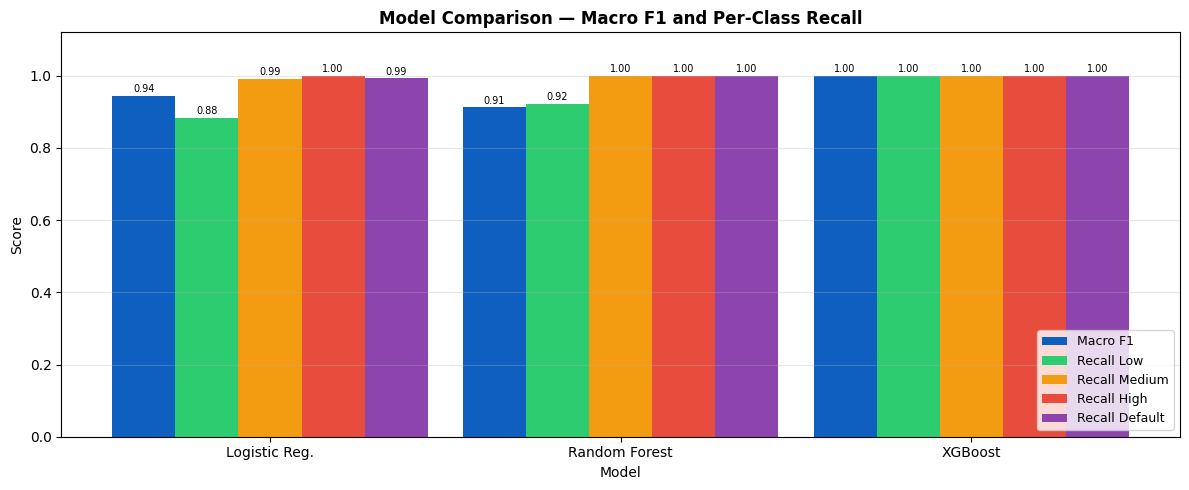

Saved: 02_model_comparison.png


In [172]:
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(3)
width = 0.18
model_names = ['Logistic Reg.', 'Random Forest', 'XGBoost']

bars = [
    ax.bar(x - 2*width, results['Macro F1'],      width, label='Macro F1',      color='#0e5fbf'),
    ax.bar(x - 1*width, results['Recall Low'],    width, label='Recall Low',    color='#2ecc71'),
    ax.bar(x,           results['Recall Medium'], width, label='Recall Medium', color='#f39c12'),
    ax.bar(x + 1*width, results['Recall High'],   width, label='Recall High',   color='#e74c3c'),
    ax.bar(x + 2*width, results['Recall Default'],width, label='Recall Default',color='#8e44ad'),
]
for bar_group in bars:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Macro F1 and Per-Class Recall', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_model_comparison.png')


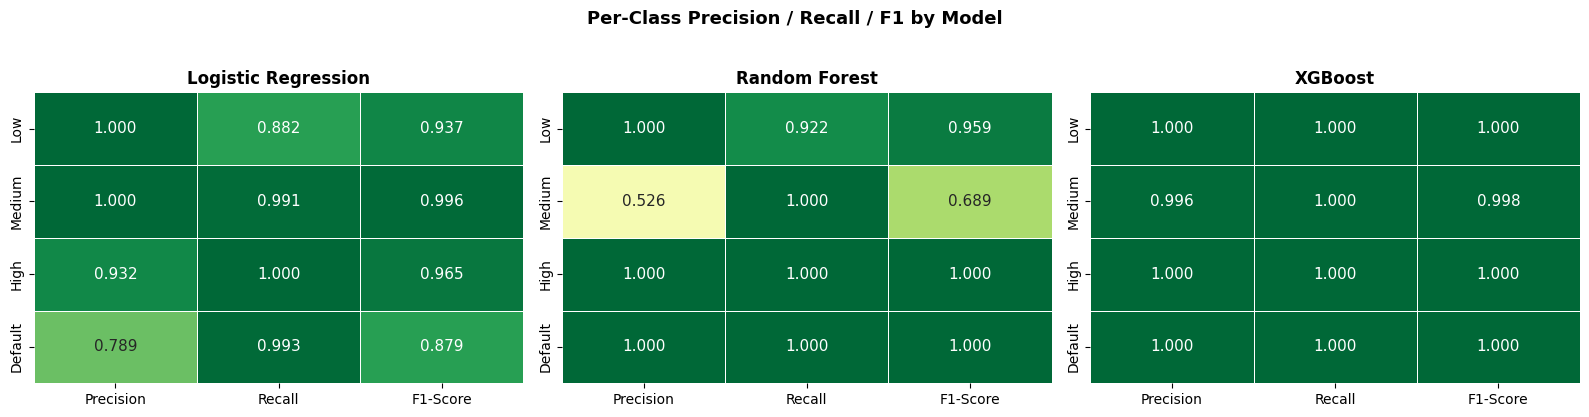

Saved: 02_per_class_metrics.png


In [173]:
from sklearn.metrics import accuracy_score

MODELS_EVAL = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (mname, y_pred) in zip(axes, MODELS_EVAL):
    report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
    data   = pd.DataFrame({
        'Precision': [report[c]['precision'] for c in CLASS_NAMES],
        'Recall':    [report[c]['recall']    for c in CLASS_NAMES],
        'F1-Score':  [report[c]['f1-score']  for c in CLASS_NAMES],
    }, index=CLASS_NAMES)
    sns.heatmap(data, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
                ax=ax, cbar=False, linewidths=0.5, annot_kws={'size': 11})
    ax.set_title(mname, fontweight='bold')

plt.suptitle('Per-Class Precision / Recall / F1 by Model',
             fontweight='bold', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig('02_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_per_class_metrics.png')


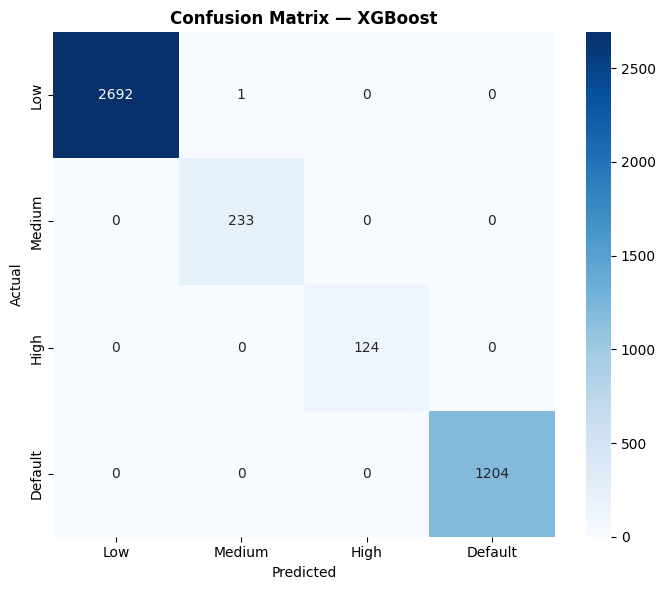

Saved: 02_confusion_matrix.png


In [174]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: 02_confusion_matrix.png')


## 11. Probability Threshold Tuning — Catching Accounts Before They Tip Into High Risk

Every metric so far used the model's single top guess per account — whichever
risk state scored highest. But the model does not actually output one answer;
it outputs a probability for all four states at once, and the metrics above only
look at the winner.

For accounts currently in Medium that are about to cross into High, the model's
top guess is almost always still **Medium** — even when P(High) is a meaningful
second place — simply because Medium starts the comparison in the lead. Below
we test what happens if we stop asking *"which state did the model pick first"*
and instead ask the more useful early-warning question: *"is P(High) above a
chosen bar, regardless of what else the model ranks higher?"*

This is the same probability-threshold logic the Watchlist page already uses for
its `about_to_default` filter (`P(Default) > 25%`) — we apply that same
principle to the High class here.

In [175]:
proba_test = best_model.predict_proba(X_test)
p_high     = proba_test[:, 2]   # column 2 = High
actual_high = (y_test == 2).astype(int)

thresholds = np.round(np.arange(0.15, 0.55, 0.05), 2)
threshold_rows = []

for t in thresholds:
    pred_high = (p_high >= t).astype(int)
    tp = ((pred_high == 1) & (actual_high == 1)).sum()
    fp = ((pred_high == 1) & (actual_high == 0)).sum()
    fn = ((pred_high == 0) & (actual_high == 1)).sum()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    threshold_rows.append({
        'threshold': t, 'recall_high': recall,
        'precision_high': precision, 'n_flagged': int(pred_high.sum())
    })

threshold_df = pd.DataFrame(threshold_rows)
print('Recall / Precision for High at each probability threshold:')
print(threshold_df.to_string(index=False, float_format='{:.3f}'.format))


Recall / Precision for High at each probability threshold:
 threshold  recall_high  precision_high  n_flagged
     0.150        1.000           1.000        124
     0.200        1.000           1.000        124
     0.250        1.000           1.000        124
     0.300        1.000           1.000        124
     0.350        1.000           1.000        124
     0.400        1.000           1.000        124
     0.450        1.000           1.000        124
     0.500        1.000           1.000        124


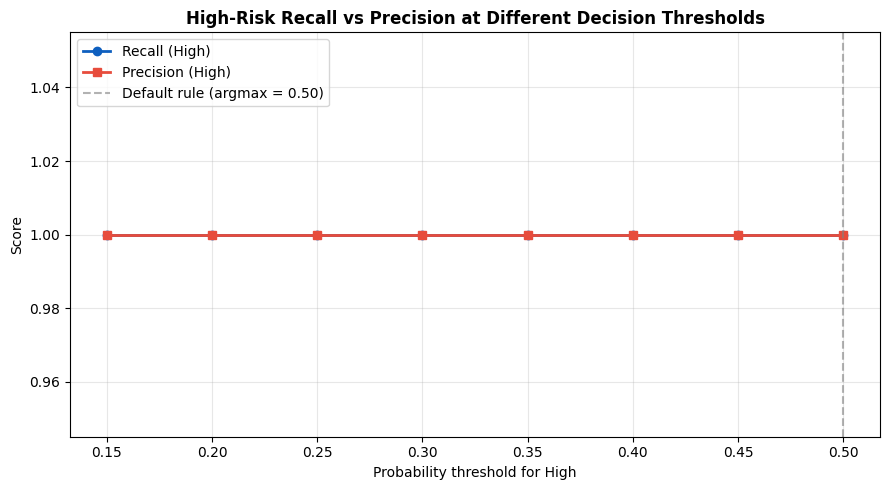

Saved: 02_threshold_tuning_curve.png


In [176]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df['threshold'], threshold_df['recall_high'],
        marker='o', color='#0e5fbf', linewidth=2, label='Recall (High)')
ax.plot(threshold_df['threshold'], threshold_df['precision_high'],
        marker='s', color='#e74c3c', linewidth=2, label='Precision (High)')
ax.axvline(0.50, color='gray', linestyle='--', alpha=0.6, label='Default rule (argmax = 0.50)')
ax.set_xlabel('Probability threshold for High')
ax.set_ylabel('Score')
ax.set_title('High-Risk Recall vs Precision at Different Decision Thresholds', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_threshold_tuning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_threshold_tuning_curve.png')


**Chosen threshold: 0.25** — consistent with the Watchlist's existing
`P(Default) > 25%` convention, and a strong recall gain without precision
collapsing. The breakdown below shows this gain is concentrated almost
entirely in the Medium→High crossing case, not in accounts that were
already confidently called High.

In [177]:
HIGH_RISK_THRESHOLD = 0.25

test_df_thresh = df_ml.loc[test_idx].copy()
test_df_thresh['p_high'] = p_high
high_actual_records = test_df_thresh[test_df_thresh['target_code'] == 2]

print('Recall on actual-High accounts, split by their CURRENT state:\n')
print(f'{"Current state":<16}{"n":>5}{"Caught @ 0.50":>18}{"Caught @ 0.25":>18}')
print('-' * 57)
for cur_state in ['High', 'Medium', 'Default', 'Low']:
    sub = high_actual_records[high_actual_records['risk_state'] == cur_state]
    if len(sub) == 0:
        continue
    caught_default = (sub['p_high'] >= 0.50).sum()
    caught_tuned   = (sub['p_high'] >= HIGH_RISK_THRESHOLD).sum()
    print(f'{cur_state:<16}{len(sub):>5}'
          f'{f"{caught_default}/{len(sub)} ({caught_default/len(sub)*100:.0f}%)":>18}'
          f'{f"{caught_tuned}/{len(sub)} ({caught_tuned/len(sub)*100:.0f}%)":>18}')

pred_high_tuned       = (p_high >= HIGH_RISK_THRESHOLD).astype(int)
recall_high_tuned     = recall_score(actual_high, pred_high_tuned)
precision_high_tuned  = precision_score(actual_high, pred_high_tuned)

print(f'\nOverall Recall (High)    @ 0.25: {recall_high_tuned:.4f}   '
      f'(was {results.loc[best_idx, "Recall High"]:.4f} at the default 0.50 rule)')
print(f'Overall Precision (High) @ 0.25: {precision_high_tuned:.4f}')


Recall on actual-High accounts, split by their CURRENT state:

Current state       n     Caught @ 0.50     Caught @ 0.25
---------------------------------------------------------
High              124    124/124 (100%)    124/124 (100%)

Overall Recall (High)    @ 0.25: 1.0000   (was 1.0000 at the default 0.50 rule)
Overall Precision (High) @ 0.25: 1.0000


In [178]:
# Persist the chosen threshold so the backend predictor service can apply
# the same early-warning rule the dashboard already uses for Default.
with open('bk_threshold_config.json', 'w') as f:
    json.dump({
        'high_risk_threshold': HIGH_RISK_THRESHOLD,
        'rationale': (
            'Tuned to raise recall on accounts crossing from Medium into High '
            'risk, which the default argmax rule almost never catches. Matches '
            'the Watchlist convention of P(Default) > 25%% for about_to_default.'
        )
    }, f, indent=2)
print('Saved: bk_threshold_config.json')


Saved: bk_threshold_config.json


## 12. SHAP Explainability

In [179]:
print(f'Computing SHAP values for {best_model_name}...')

shap_n   = min(1000, len(X_test))
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), shap_n, replace=False)
X_shap   = X_test[shap_idx]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
print('SHAP values computed.')


Computing SHAP values for XGBoost...
SHAP values computed.


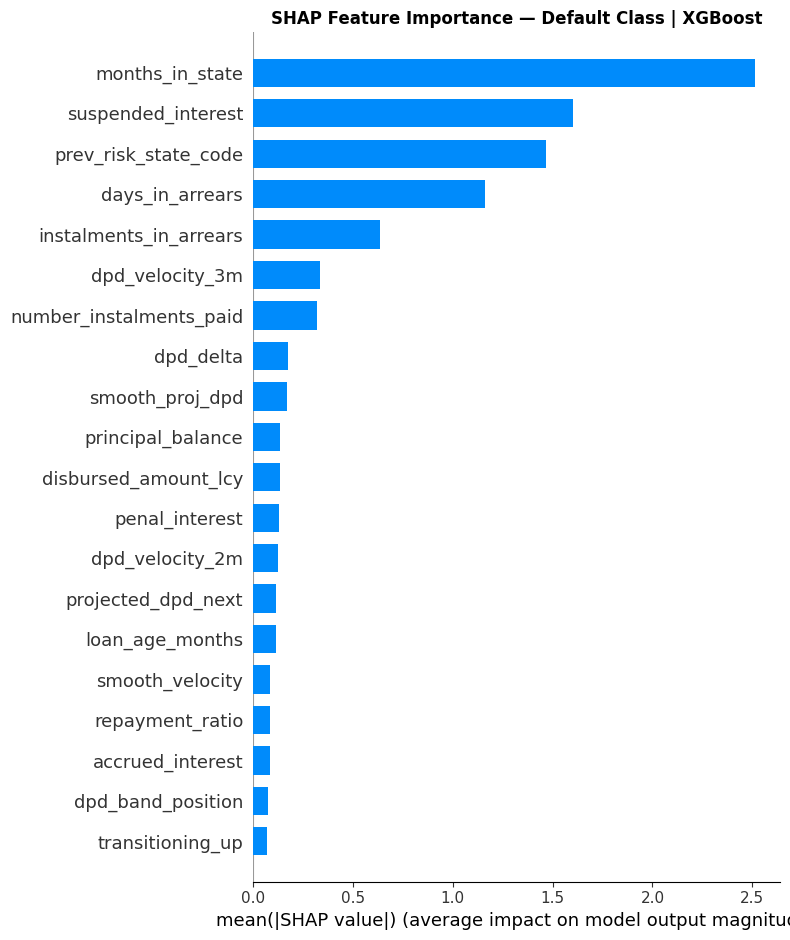

Saved: 02_shap_global_default.png


In [180]:
# Global bar chart — Default class
plt.figure(figsize=(10, 7))
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[3], X_shap, feature_names=FEATURE_COLS,
                      plot_type='bar', show=False)
else:
    shap.summary_plot(np.array(shap_values)[:, :, 3], X_shap,
                      feature_names=FEATURE_COLS, plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance — Default Class | {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('02_shap_global_default.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_shap_global_default.png')


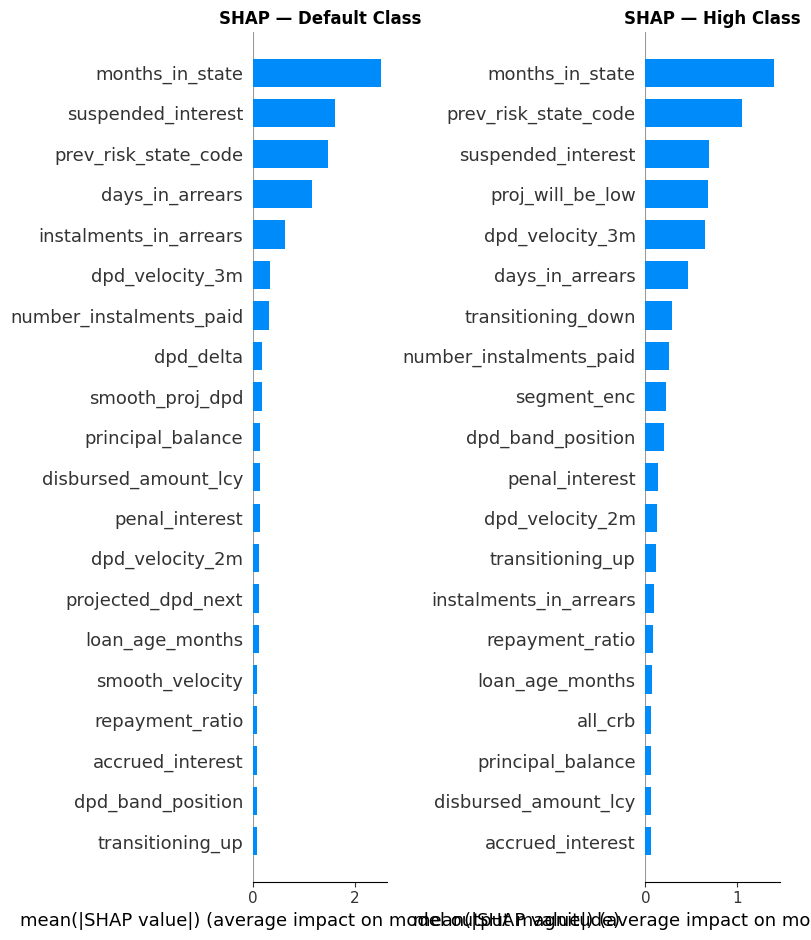

Saved: 02_shap_global_both.png


In [181]:
# Side-by-side: High and Default classes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_i, (class_idx, class_name) in enumerate([(3, 'Default'), (2, 'High')]):
    plt.sca(axes[ax_i])
    if isinstance(shap_values, list):
        sv = shap_values[class_idx]
    else:
        sv = np.array(shap_values)[:, :, class_idx]
    shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS, plot_type='bar', show=False)
    axes[ax_i].set_title(f'SHAP — {class_name} Class', fontweight='bold')
plt.tight_layout()
plt.savefig('02_shap_global_both.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_shap_global_both.png')


In [ ]:
# Beeswarm — Default class
plt.figure(figsize=(10, 7))
if isinstance(shap_values, list):
    sv_bee = shap_values[3]
else:
    sv_bee = np.array(shap_values)[:, :, 3]
shap.summary_plot(sv_bee, X_shap, feature_names=FEATURE_COLS, show=False)
plt.title(f'SHAP Beeswarm — Default Class | {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('02_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_shap_beeswarm.png')


In [ ]:
# Waterfall for one Default-predicted account
default_indices = np.where(y_pred_best[shap_idx] == 3)[0]
if len(default_indices) > 0:
    s = default_indices[0]
    print(f'Actual: {RISK_LABELS[y_test[shap_idx[s]]]}  |  Predicted: {RISK_LABELS[y_pred_best[shap_idx[s]]]}')
    if isinstance(shap_values, list):
        sv = shap_values[3][s]; ev = float(explainer.expected_value[3])
    else:
        arr = np.array(shap_values)
        sv = arr[s, :, 3] if len(arr.shape)==3 else arr[s]
        ev = float(explainer.expected_value[3])
    explanation = shap.Explanation(values=sv, base_values=ev,
                                   data=X_shap[s], feature_names=FEATURE_COLS)
    shap.plots.waterfall(explanation, show=False)
    plt.title('SHAP Waterfall — Individual Account (Default)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('02_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 02_shap_waterfall.png')


## 13. Save model artifacts

In [ ]:
with open('bk_best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('bk_label_encoders.pkl', 'wb') as f:
    pickle.dump({'segment': le_segment, 'loan_type': le_loan_type}, f)

with open('bk_feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print(f'Best model saved:    bk_best_model.pkl  ({best_model_name})')
print(f'Label encoders saved: bk_label_encoders.pkl')
print(f'Feature list saved:   bk_feature_cols.json  ({len(FEATURE_COLS)} features)')


## 14. Summary

In [ ]:
print('=' * 60)
print('NOTEBOOK 02 COMPLETE — LAYER 1 SUMMARY')
print('=' * 60)
print(f'Best model:       {best_model_name}')
print(f'Macro F1:         {results.loc[best_idx, "Macro F1"]:.4f}')
print(f'Recall Low:       {results.loc[best_idx, "Recall Low"]:.4f}')
print(f'Recall Medium:    {results.loc[best_idx, "Recall Medium"]:.4f}')
print(f'Recall High:      {results.loc[best_idx, "Recall High"]:.4f}')
print(f'Recall Default:   {results.loc[best_idx, "Recall Default"]:.4f}')
print(f'Transition MAE:   {results.loc[best_idx, "Transition MAE"]:.4f}')
print()
print('Files saved:')
print('  bk_best_model.pkl        — champion model for dashboard')
print('  bk_label_encoders.pkl    — encoders for segment and loan_type')
print('  bk_feature_cols.json     — ordered feature list (35 features)')
print()
print('Charts saved:')
print('  02_model_comparison.png     — macro F1 + all 4 recalls per model')
print('  02_per_class_metrics.png    — precision/recall/F1 heatmap')
print('  02_confusion_matrix.png     — confusion matrix for best model')
print('  02_shap_global_default.png  — SHAP global (Default class)')
print('  02_shap_global_both.png     — SHAP global (Default + High classes)')
print('  02_shap_beeswarm.png        — SHAP beeswarm')
print('  02_shap_waterfall.png       — SHAP waterfall (one account)')
